# DoubleIntegrator - Stage 4b - Symbolic-Jacobian Safe Adaptation

Verify and benchmark analytic safety sensitivities.


## 1. Setup

Load dependencies and configuration.


In [1]:
import sys, warnings, time, statistics, copy
from pathlib import Path
warnings.filterwarnings("ignore")

_p = Path.cwd()
while not (_p / "src" / "sdpc").exists():
    _p = _p.parent
sys.path.insert(0, str(_p / "src"))

import torch
try:
    import pandas as pd
except Exception:
    pd = None

from sdpc.config import load_config
from sdpc.registry import make_system
from sdpc.sindy import load_model
from sdpc.adaptation.analytic import sindy_step
from sdpc.adaptation.rollout import predict_rollout, clamp_action
from sdpc.adaptation.reference import zero_xi_grads
from sdpc.adaptation.barrier import rollout_barrier_loss
from sdpc.adaptation import SymbolicSafetyJacobian, SafeAdaptationConfig, run_safe_adaptation
from sdpc.eval import sample_scenario

SYSTEM = "double_integrator"
device = torch.device("cpu")
system = make_system(SYSTEM, device=device)
CONFIGS = Path.cwd().parent / "configs"
RESULTS = Path.cwd().parent / "results"

print(f"System        : {SYSTEM}")
print(f"State dim nx  : {system.nx}")
print(f"Control dim nu: {system.nu}")
print(f"Input bounds  : [{system.umin}, {system.umax}]")
print(f"State bounds  : [{system.xmin}, {system.xmax}]")
print(f"Discrete model: {system.is_discrete}")

System        : double_integrator
State dim nx  : 2
Control dim nu: 2
Input bounds  : [-1.0, 1.0]
State bounds  : [-5.0, 5.0]
Discrete model: True


In [ ]:
cfg = load_config(CONFIGS / "safe.yaml")
safe_cfg = cfg.get("safe", {})
action_scale = safe_cfg.get("action_scale", cfg.get("action_scale", 1.0))
barrier_kind = safe_cfg.get("barrier_kind", "relaxed_log")
barrier_eps = safe_cfg.get("barrier_eps", 1e-6)
safety_loss_tol = safe_cfg.get("safety_loss_tol", 1e-10)
horizon = safe_cfg.get("horizon", 20)

from sdpc.io import find_policy_checkpoint
policy_path = find_policy_checkpoint(RESULTS, cfg)
policy = load_model(policy_path, device=device).eval()

# Exact perturbed dynamics in SINDy form. This is used for safety prediction and derivatives.
sindy = system.perturbed_sindy_model(cfg)
def make_pred_plant(method="rk4"):
    return lambda x, u: sindy_step(sindy, x, u, system=system, method=method)
pred_plants = {m: make_pred_plant(m) for m in ["euler", "rk4"]}
pred_plant = pred_plants[safe_cfg.get("integration_method", "rk4")]
plant = system.perturbed_plant(cfg)
spec = system.safety_specs(cfg)

print("Sparse checkpoint      :", policy_path)
print("Exact perturbed dynamics: SINDy-style model from system.perturbed_sindy_model(cfg)")
print("Safety constraints     :", [c.name for c in spec.state_constraints])
print("Control-rate limit     :", spec.control_rate is not None)
print("Barrier kind           :", barrier_kind)

## 2. Verify Symbolic Safety Gradients

Check the expected behavior.


In [3]:
ell = cfg["ellipse"]
x0_bad = torch.tensor([[ell.get("c", 0.0) + 0.25, ell.get("d", 0.0) + 0.25]], dtype=torch.float32, device=device)
r_target = torch.tensor(cfg.get("ref_center", [-3.0, 3.0]), dtype=torch.float32, device=device).view(1, 1, system.nx)
r_horizon = r_target.expand(1, horizon, system.nx).contiguous()

policy_ag, policy_sym = copy.deepcopy(policy), copy.deepcopy(policy)

zero_xi_grads(policy_ag)
x_roll, u_roll = predict_rollout(
    policy_ag, pred_plant, x0_bad, r_horizon, horizon,
    umin=system.umin, umax=system.umax, action_scale=action_scale, grad=True,
)
# Compare the same differentiated part as symbolic: future states x1..xN.
# x0 is fixed, so it has zero policy-parameter sensitivity.
loss_ag, _, _ = rollout_barrier_loss(
    x_roll[:, 1:, :], spec, kind=barrier_kind, eps=barrier_eps, u_traj=u_roll,
)
print("barrier loss on this rollout:", float(loss_ag.detach()))
loss_ag.backward()
raw_ag = [(-p.grad.detach().clone() if p.grad is not None else torch.zeros_like(p)) for p in policy_ag.Xi]
zero_xi_grads(policy_ag)

with torch.no_grad():
    x_roll2, u_roll2 = predict_rollout(
        policy_sym, pred_plant, x0_bad, r_horizon, horizon,
        umin=system.umin, umax=system.umax, action_scale=action_scale, grad=False,
    )
safety_jac = SymbolicSafetyJacobian(
    sindy, policy_sym, system.umin, system.umax,
    system=system, action_scale=action_scale,
    integration_method=safe_cfg.get("integration_method", "rk4"),
)
raw_sym, loss_sym = safety_jac.rollout_sensitivity_grad(
    x_roll2, u_roll2, r_horizon, spec, kind=barrier_kind, eps=barrier_eps,
)
print("symbolic-reported barrier loss:", loss_sym)

print(f"{'output':>8} {'autograd norm':>16} {'symbolic norm':>16} {'cos_sim':>10} {'rel_diff':>10}")
for k, (a, s) in enumerate(zip(raw_ag, raw_sym)):
    denom = a.norm().item() + 1e-12
    if torch.isfinite(a).all() and torch.isfinite(s).all() and a.norm() > 0 and s.norm() > 0:
        cos = torch.nn.functional.cosine_similarity(a.flatten(), s.flatten(), dim=0).item()
    else:
        cos = float("nan")
    rel = (a - s).norm().item() / denom
    print(f"{k:>8} {a.norm().item():>16.4e} {s.norm().item():>16.4e} {cos:>10.6f} {rel:>10.2e}")

barrier loss on this rollout: 393904390144.0
symbolic-reported barrier loss: 393904390144.0
  output    autograd norm    symbolic norm    cos_sim   rel_diff
       0       1.7125e+12       1.7125e+12   1.000000   2.11e-07
       1       2.8454e+13       2.8454e+13   1.000000   8.10e-08


## 3. Full Safe Adaptation Comparison

Compare both safety backends.


In [4]:
data = sample_scenario(system, cfg, cfg.get("seed", 0), device)
constraint_modes = [("barrier", barrier_kind), ("relu", "relu_hinge")]
integrator_modes = ["euler"]
backend_modes = ["autograd", "symbolic"]

run_modes = [
    {"name": f"{backend}_{cname}_{method}", "backend": backend, "constraint": cname, "barrier": bkind, "method": method}
    for cname, bkind in constraint_modes
    for method in integrator_modes
    for backend in backend_modes
]

results, run_wall = {}, {}
for mode in run_modes:
    pol = copy.deepcopy(policy)
    safe_run_cfg = {**safe_cfg, "safety_backend": mode["backend"], "barrier_kind": mode["barrier"], "integration_method": mode["method"]}
    safe_run_cfg.setdefault("action_scale", cfg.get("action_scale", 1.0))
    scfg = SafeAdaptationConfig(**safe_run_cfg)
    t0 = time.perf_counter()
    results[mode["name"]] = run_safe_adaptation(
        pol, plant, data, spec, scfg,
        umin=system.umin, umax=system.umax,
        pred_plant=pred_plants[mode["method"]],
        derivative_model=sindy,
        system=system,
    )
    elapsed = time.perf_counter() - t0
    run_wall[mode["name"]] = elapsed
    logs = results[mode["name"]]["logs"]
    n_safe = sum(l["predicted_safe"] for l in logs)
    total_iters = sum(l["safety_iters"] for l in logs)
    print(f"[{mode['name']:24s}] wall={elapsed:7.3f}s  predicted-safe={n_safe}/{len(logs)}  total safety iters={total_iters}")

print("\nFull safe-adaptation wall-time speedups, paired by constraint and integrator")
print(f"{'constraint':>10} {'integrator':>10} {'autograd (s)':>12} {'symbolic (s)':>12} {'speedup':>9} {'max |dx|':>11} {'max |du|':>11}")
for cname, _ in constraint_modes:
    for method in integrator_modes:
        ag = f"autograd_{cname}_{method}"
        sy = f"symbolic_{cname}_{method}"
        x_diff = (results[ag]["x_traj"] - results[sy]["x_traj"]).abs().max().item()
        u_diff = (results[ag]["u_traj"] - results[sy]["u_traj"]).abs().max().item()
        print(f"{cname:>10} {method:>10} {run_wall[ag]:>12.4f} {run_wall[sy]:>12.4f} {run_wall[ag] / max(run_wall[sy], 1e-9):>8.2f}x {x_diff:>11.3e} {u_diff:>11.3e}")


KeyboardInterrupt



## 4. One-Step Safety-Gradient Timing

Measure safety-gradient runtime.


In [7]:
def _sync():
    if torch.cuda.is_available() and device.type == "cuda":
        torch.cuda.synchronize()

def _loss_for_kind(x_r, u_r, penalty_kind):
    loss, _, _ = rollout_barrier_loss(x_r, spec, kind=penalty_kind, eps=barrier_eps, u_traj=u_r)
    return loss

def time_backend(backend, horizon, *, penalty_kind, method, include_rollout=False, n_rep=20, warmup=5):
    r_h = r_target.expand(1, horizon, system.nx).contiguous()
    pol = copy.deepcopy(policy)
    pred = pred_plants[method]
    sj = None
    if backend == "symbolic":
        sj = SymbolicSafetyJacobian(sindy, pol, system.umin, system.umax, system=system, action_scale=action_scale, integration_method=method)

    def once():
        if backend == "symbolic":
            with torch.no_grad():
                x_r, u_r = predict_rollout(pol, pred, x0_bad, r_h, horizon, umin=system.umin, umax=system.umax, action_scale=action_scale, grad=False)
                loss = _loss_for_kind(x_r, u_r, penalty_kind)
            if not include_rollout:
                _sync(); t0 = time.perf_counter()
                if float(loss.detach()) > safety_loss_tol:
                    sj.rollout_sensitivity_grad(x_r, u_r, r_h, spec, kind=penalty_kind, eps=barrier_eps)
                _sync(); return time.perf_counter() - t0, float(loss.detach())
            if float(loss.detach()) > safety_loss_tol:
                sj.rollout_sensitivity_grad(x_r, u_r, r_h, spec, kind=penalty_kind, eps=barrier_eps)
            return None, float(loss.detach())

        zero_xi_grads(pol)
        x_r, u_r = predict_rollout(pol, pred, x0_bad, r_h, horizon, umin=system.umin, umax=system.umax, action_scale=action_scale, grad=True)
        loss = _loss_for_kind(x_r, u_r, penalty_kind)
        if not include_rollout:
            _sync(); t0 = time.perf_counter()
            if float(loss.detach()) > safety_loss_tol:
                loss.backward()
            _sync(); elapsed = time.perf_counter() - t0
            zero_xi_grads(pol)
            return elapsed, float(loss.detach())
        if float(loss.detach()) > safety_loss_tol:
            loss.backward()
        zero_xi_grads(pol)
        return None, float(loss.detach())

    for _ in range(warmup):
        if include_rollout:
            _sync(); t0 = time.perf_counter(); once(); _sync()
        else:
            once()
    times, losses = [], []
    for _ in range(n_rep):
        if include_rollout:
            _sync(); t0 = time.perf_counter(); _, loss = once(); _sync(); elapsed = time.perf_counter() - t0
        else:
            elapsed, loss = once()
        times.append(elapsed); losses.append(loss)
    return statistics.median(times), statistics.median(losses)

for include_rollout, title in [(False, "gradient-only"), (True, "rollout+gradient")]:
    print(f"\n{title} speedups, paired by constraint and integrator")
    print(f"{'horizon':>7} {'constraint':>10} {'integrator':>10} {'autograd (ms)':>14} {'symbolic (ms)':>14} {'speedup':>9}")
    for H in [5, 10, 20, 40]:
        for cname, kind in constraint_modes:
            for method in integrator_modes:
                ag_t, _ = time_backend("autograd", H, penalty_kind=kind, method=method, include_rollout=include_rollout)
                sy_t, _ = time_backend("symbolic", H, penalty_kind=kind, method=method, include_rollout=include_rollout)
                print(f"{H:>7} {cname:>10} {method:>10} {1e3*ag_t:>14.4f} {1e3*sy_t:>14.4f} {ag_t / max(sy_t, 1e-12):>8.2f}x")


gradient-only speedups, paired by constraint and integrator
horizon constraint integrator  autograd (ms)  symbolic (ms)   speedup
      5    barrier      euler         0.9396         2.3614     0.40x
      5       relu      euler         0.7682         1.0552     0.73x
     10    barrier      euler         2.1646         1.6285     1.33x
     10       relu      euler         1.7202         1.1771     1.46x
     20    barrier      euler         2.7001         1.6554     1.63x
     20       relu      euler         2.2976         1.1141     2.06x
     40    barrier      euler         4.7616         1.7245     2.76x
     40       relu      euler         4.4156         1.4247     3.10x

rollout+gradient speedups, paired by constraint and integrator
horizon constraint integrator  autograd (ms)  symbolic (ms)   speedup
      5    barrier      euler         1.7389         1.7464     1.00x
      5       relu      euler         1.5234         1.4881     1.02x
     10    barrier      euler      

## 5. Trajectory Visualization

Visualize the closed-loop response.


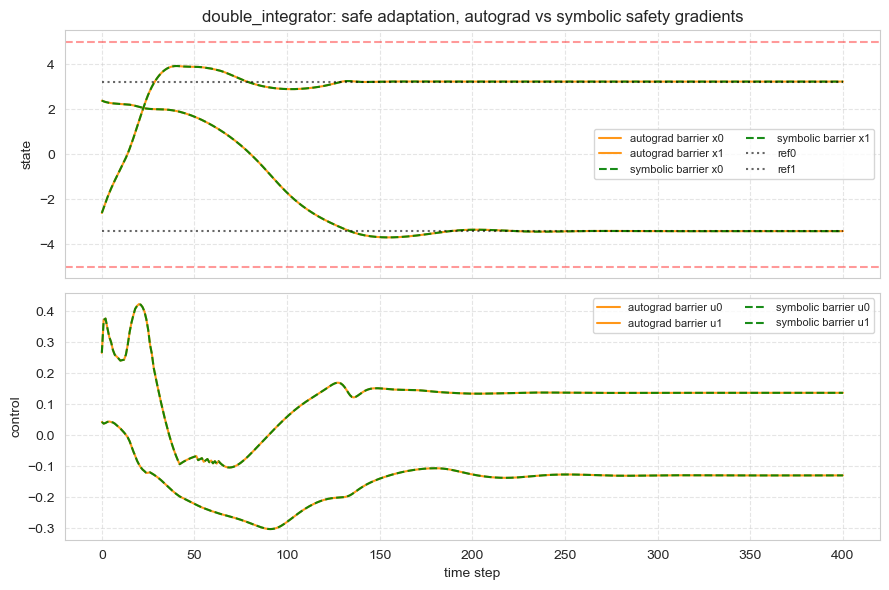

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


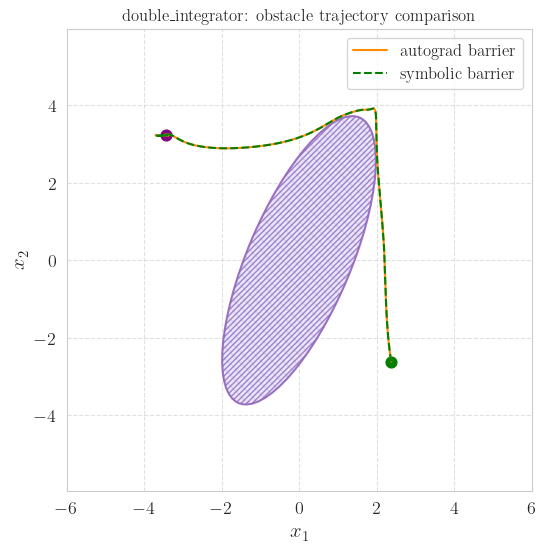

In [9]:
from sdpc.plotting import plot_states_and_controls, plot_trajectories_with_ellipse
import matplotlib.pyplot as plt

plot_states_and_controls(
    [
        {"x": results["autograd_barrier_euler"]["x_traj"], "u": results["autograd_barrier_euler"]["u_traj"], "label": "autograd barrier", "color": "darkorange"},
        {"x": results["symbolic_barrier_euler"]["x_traj"], "u": results["symbolic_barrier_euler"]["u_traj"], "label": "symbolic barrier", "color": "green", "linestyle": "--"},
    ],
    r_traj=data["r"], xmin=cfg.get("safe_xmin", system.xmin), xmax=cfg.get("safe_xmax", system.xmax),
    title=f"{SYSTEM}: safe adaptation, autograd vs symbolic safety gradients",
)
plt.show()

e = cfg["ellipse"]
plot_trajectories_with_ellipse(
    [
        {"traj": results["autograd_barrier_euler"]["x_traj"], "label": "autograd barrier", "color": "darkorange"},
        {"traj": results["symbolic_barrier_euler"]["x_traj"], "label": "symbolic barrier", "color": "green", "linestyle": "--"},
    ],
    r=data["r"], p=e["p"], b=e["b"], c=e["c"], d=e["d"], theta=e.get("theta", 0.0),
    xmin=-6, xmax=6, title=f"{SYSTEM}: obstacle trajectory comparison",
)
plt.show()

**Takeaway.** For DoubleIntegrator, symbolic safety gradients use analytic derivatives of the sparse policy and exact perturbed dynamics.
